In [1]:
from ase.io import read, write
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
atoms = read("./water_charges.extxyz", index=":")

In [18]:
element_list = []
charges_list = []
for i in range(len(atoms)):
    element_list += atoms[i].get_chemical_symbols()
    charges_list += list(atoms[i].get_charges())

In [19]:
df = pd.DataFrame({"Atoms": element_list, "Predicted Charges": charges_list})
df

,Atoms,Predicted Charges
0,O,-3.459064
1,H,1.702539
2,H,1.770903
3,O,-3.453239
4,H,1.640691
...,...,...
960187,H,1.714097
960188,H,1.619501
960189,O,-3.392575
960190,H,1.846166


1.5015516896299589e-06


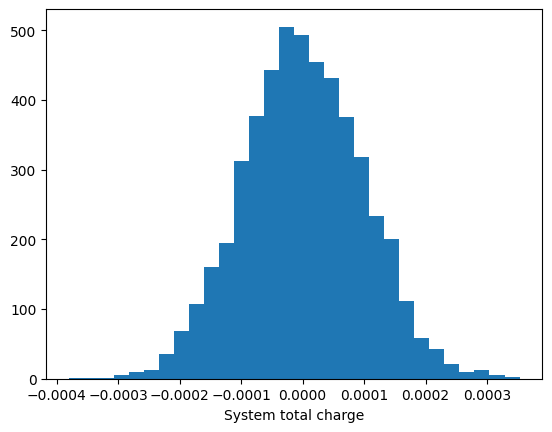

In [20]:
count = 0
system_charge = []
for i in atoms:
    system_charge.append(sum(df["Predicted Charges"].iloc[count:count+len(i)]))
    count += len(i)

plt.hist(np.array(system_charge), bins=30)
plt.xlabel("System total charge")
print(np.array(system_charge).mean())

2.3461745150511812e-08


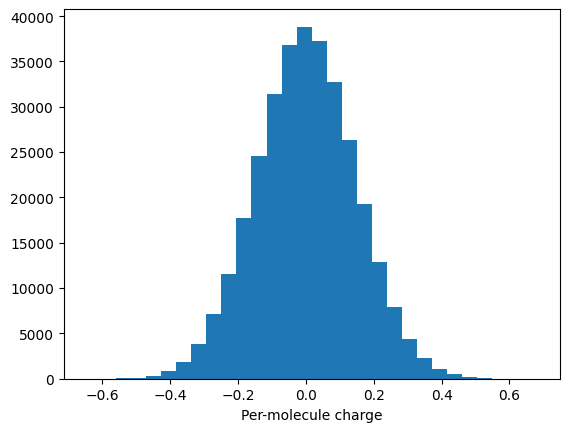

In [21]:
molecule_charge = []
for i in range(0, len(df), 3):
    molecule_charge.append(sum(df["Predicted Charges"].iloc[i:i+3]))

plt.hist(np.array(molecule_charge), bins=30)
plt.xlabel("Per-molecule charge")

print(np.array(molecule_charge).mean())

(0.0, 86685.0)

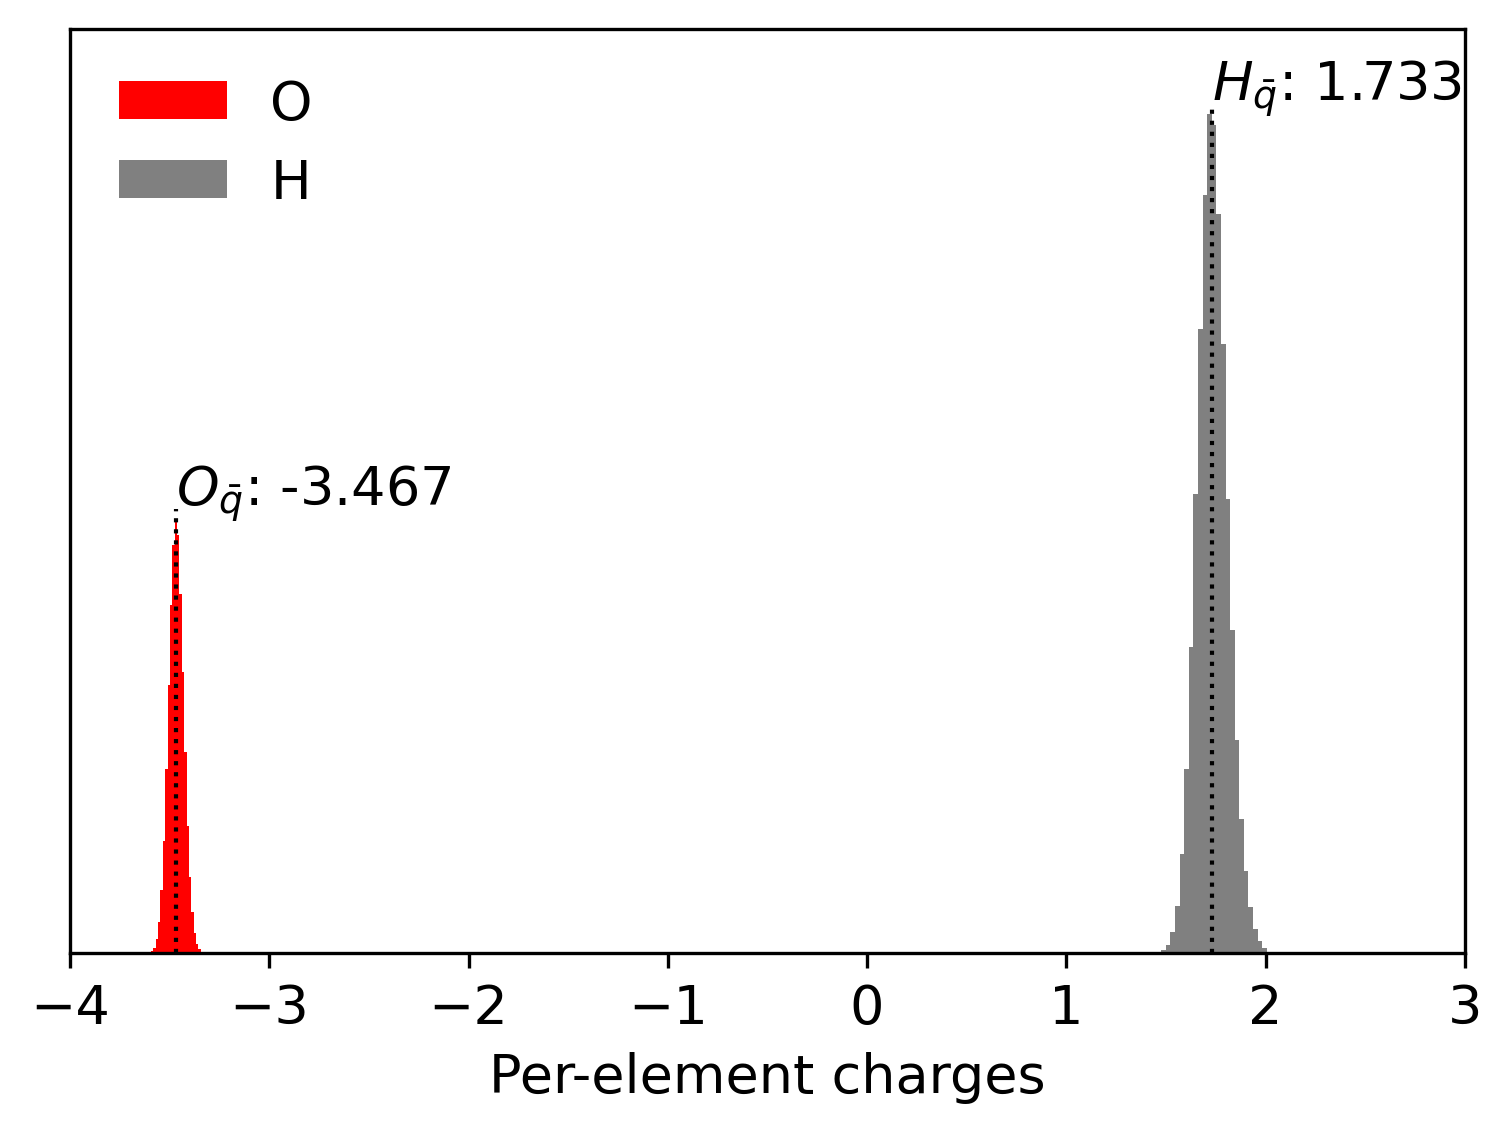

In [28]:
O = df[df["Atoms"] == "O"]["Predicted Charges"]
H = df[df["Atoms"] == "H"]["Predicted Charges"]

plt.figure(figsize=(6,4), dpi=300)

counts_O, bins, _ = plt.hist(O, bins=30, color='red', label="O")
counts_H, bins, _ = plt.hist(H, bins=30, color ='grey', label = "H")

plt.xlabel("Per-element charges", fontsize=13)
plt.xticks(fontsize=13)
plt.yticks([])
plt.xlim([-4,3])

plt.legend(frameon=False, fontsize=13)

O_mean = round(float(O.mean()), 3)
H_mean = round(float(H.mean()), 3)

plt.vlines(O_mean, 0, max(counts_O) + 1000, linestyles=':', linewidth=1, color='black')
plt.vlines(H_mean, 0, max(counts_H) + 1000, linestyles=':', linewidth=1, color='black')

plt.annotate(rf"$O_{{\bar{{q}}}}$: {O_mean}", (O_mean, max(counts_O) + 1300), fontsize=13)
plt.annotate(rf"$H_{{\bar{{q}}}}$: {H_mean}", (H_mean, max(counts_H) + 1300), fontsize=13)

plt.ylim([0, max(counts_H)+8000])